In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

from src.physics.analytical_potentials import GornetDesmoratPotential
from src.data.generation import DeformationSampler
from src.training.loss import SobolevLoss
from src.models.layers import PositiveLinear


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution sur : {device}")

# Configuration pour l'affichage
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

Exécution sur : cuda


In [ ]:
import torch
import numpy as np
import random
import os

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Seed fixé à 42.")

Seed fixé à 42.


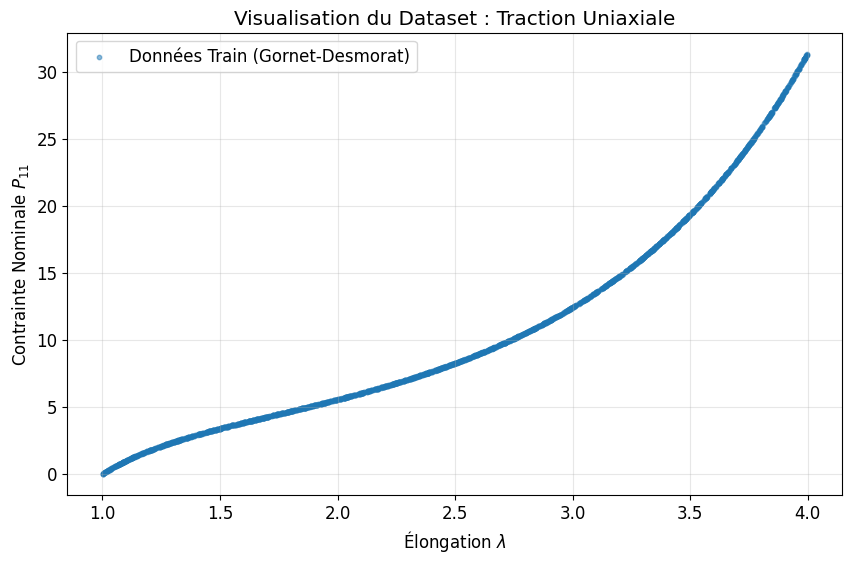

In [ ]:
# 1. Instanciation du modèle physique
gt_model = GornetDesmoratPotential(h1=1.0, h2=0.5, h3=0.1) 
gt_model.to(device)

# 2. Échantillonnage des déformations
sampler = DeformationSampler(device=device)
n_samples = 2000

F_train, lambdas_train = sampler.sample_uniaxial(n_samples, stretch_min=1.0, stretch_max=4.0)
# F_train, lambdas_train = sampler.sample_pure_shear(n_samples, stretch_min=1.0, stretch_max=4.0)
# F_train, lambdas_train = sampler.sample_biaxial(n_samples, stretch_min=1.0, stretch_max=4.0)


# 3. Calcul des contraintes cibles (P)
P_train = gt_model.compute_stress(F_train, t=None).detach()


plt.figure()
plt.scatter(lambdas_train.cpu(), P_train[:, 0, 0].cpu(), s=10, alpha=0.5, label='Données Train (Gornet-Desmorat)')
plt.title("Visualisation du Dataset : Traction Uniaxiale")
plt.xlabel(r"Élongation $\lambda$")
plt.ylabel(r"Contrainte Nominale $P_{11}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
class ICNNInvariantsModel(nn.Module):
    def __init__(self, hidden_dim=64, n_layers=3):
        super().__init__()
        
        input_dim = 2
        
        # 1. Première couche linéaire classique (Initialisation du chemin z)
        self.layer_0 = nn.Linear(input_dim, hidden_dim)
        
        # 2. Couches cachées "convexes"
        self.layers = nn.ModuleList()
        for _ in range(n_layers):
            self.layers.append(
                PositiveLinear(in_features=hidden_dim, 
                               out_features=hidden_dim, 
                               input_dim=input_dim)
            )
            
        self.layer_out = PositiveLinear(in_features=hidden_dim, 
                                        out_features=1, 
                                        input_dim=input_dim)

    def forward(self, F):
        # C = F^T * F
        C = torch.matmul(F.transpose(1, 2), F)
        
        # I1 = tr(C)
        I1 = torch.diagonal(C, dim1=1, dim2=2).sum(dim=1)
        
        # I2 = 0.5 * (I1^2 - tr(C^2))
        C_squared = torch.matmul(C, C)
        trace_C2 = torch.diagonal(C_squared, dim1=1, dim2=2).sum(dim=1)
        I2 = 0.5 * (I1**2 - trace_C2)
        
        # Vecteur d'entrée x = [I1, I2]
        x = torch.stack([I1, I2], dim=1)
        
        # --- ICNN ---
        
        #Initialisation
        z = self.layer_0(x)
        z = torch.nn.functional.softplus(z)
        
        #Boucle sur les couches cachées
        for layer in self.layers:
            # PositiveLinear combine l'état précédent z et l'entrée x
            z = layer(z_prev=z, x=x) 
            z = torch.nn.functional.softplus(z)
        
        # Sortie (Energie W)
        W = self.layer_out(z_prev=z, x=x)
        
        return W


model = ICNNInvariantsModel(hidden_dim=64, n_layers=3).to(device)
print(model)

ICNNInvariantsModel(
  (layer_0): Linear(in_features=2, out_features=64, bias=True)
  (layers): ModuleList(
    (0-2): 3 x PositiveLinear()
  )
  (layer_out): PositiveLinear()
)


In [ ]:
class SimpleInvariantsModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, F):
        # Calcul des invariants
        # C = F.T @ F
        C = torch.matmul(F.transpose(1, 2), F)
        
        # I1 = tr(C)
        I1 = torch.diagonal(C, dim1=1, dim2=2).sum(dim=1)
        
        # I2 = 0.5 * (I1^2 - tr(C^2))
        C_squared = torch.matmul(C, C)
        trace_C2 = torch.diagonal(C_squared, dim1=1, dim2=2).sum(dim=1)
        I2 = 0.5 * (I1**2 - trace_C2)
        
        invariants = torch.stack([I1, I2], dim=1)
        
        #Passage dans le réseau dense pour prédire l'énergie W
        W = self.net(invariants)
        return W

model = SimpleInvariantsModel(hidden_dim=64).to(device)
print(model)

SimpleInvariantsModel(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Softplus(beta=1.0, threshold=20.0)
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Softplus(beta=1.0, threshold=20.0)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


Début de l'entraînement...
Epoch 20/1500 | Loss: 6.8122e+08
Epoch 40/1500 | Loss: 1.9595e+08
Epoch 60/1500 | Loss: 7.1804e+07
Epoch 80/1500 | Loss: 3.5953e+07
Epoch 100/1500 | Loss: 2.1069e+07
Epoch 120/1500 | Loss: 1.2950e+07
Epoch 140/1500 | Loss: 9.2371e+06
Epoch 160/1500 | Loss: 4.1805e+06
Epoch 180/1500 | Loss: 3.0201e+06
Epoch 200/1500 | Loss: 1.9357e+06
Epoch 220/1500 | Loss: 9.8726e+05
Epoch 240/1500 | Loss: 5.9702e+05
Epoch 260/1500 | Loss: 5.7392e+05
Epoch 280/1500 | Loss: 1.6837e+05
Epoch 300/1500 | Loss: 2.8670e+05
Epoch 320/1500 | Loss: 1.4822e+05
Epoch 340/1500 | Loss: 2.1157e+04
Epoch 360/1500 | Loss: 1.7374e+04
Epoch 380/1500 | Loss: 3.2229e+04
Epoch 400/1500 | Loss: 8.8931e+03
Epoch 420/1500 | Loss: 2.3846e+03
Epoch 440/1500 | Loss: 2.2474e+03
Epoch 460/1500 | Loss: 3.4703e+03
Epoch 480/1500 | Loss: 8.7908e+02
Epoch 500/1500 | Loss: 2.3535e+02
Epoch 520/1500 | Loss: 1.9096e+02
Epoch 540/1500 | Loss: 7.3150e+01
Epoch 560/1500 | Loss: 4.7801e+01
Epoch 580/1500 | Loss: 4.

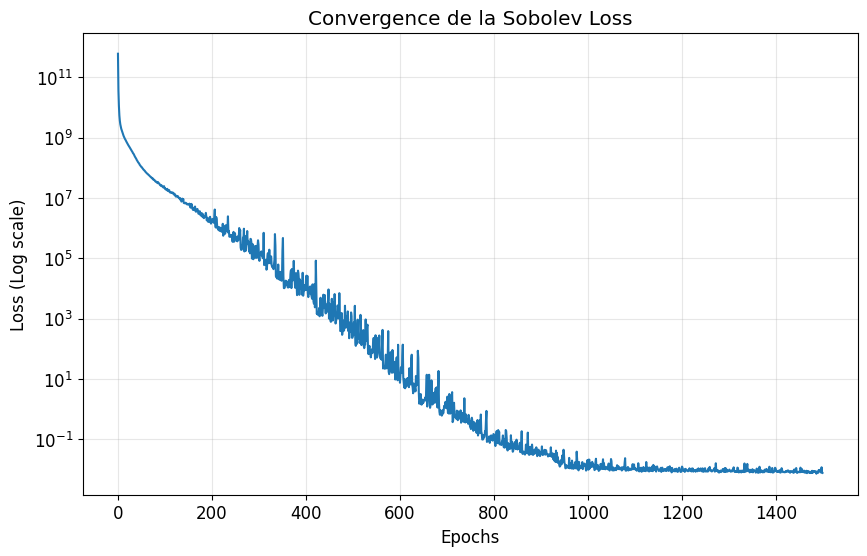

In [ ]:
# paramètres
epochs = 1500
batch_size = 32
lr = 0.005


optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = SobolevLoss()

dataset_size = F_train.shape[0]
indices = np.arange(dataset_size)
loss_history = []

print("Début de l'entraînement...")

for epoch in range(epochs):
    np.random.shuffle(indices)
    epoch_loss = 0.0
    
    for start_idx in range(0, dataset_size, batch_size):
        end_idx = min(start_idx + batch_size, dataset_size)
        batch_idx = indices[start_idx:end_idx]
        
        batch_F = F_train[batch_idx]
        batch_P = P_train[batch_idx]
        
        optimizer.zero_grad()
        
        # Sobolev Loss
        loss = criterion(model, batch_F, batch_P)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / (dataset_size / batch_size)
    loss_history.append(avg_loss)
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4e}")

plt.figure()
plt.plot(loss_history)
plt.yscale('log')
plt.title("Convergence de la Sobolev Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (Log scale)")
plt.grid(True, alpha=0.3)
plt.show()

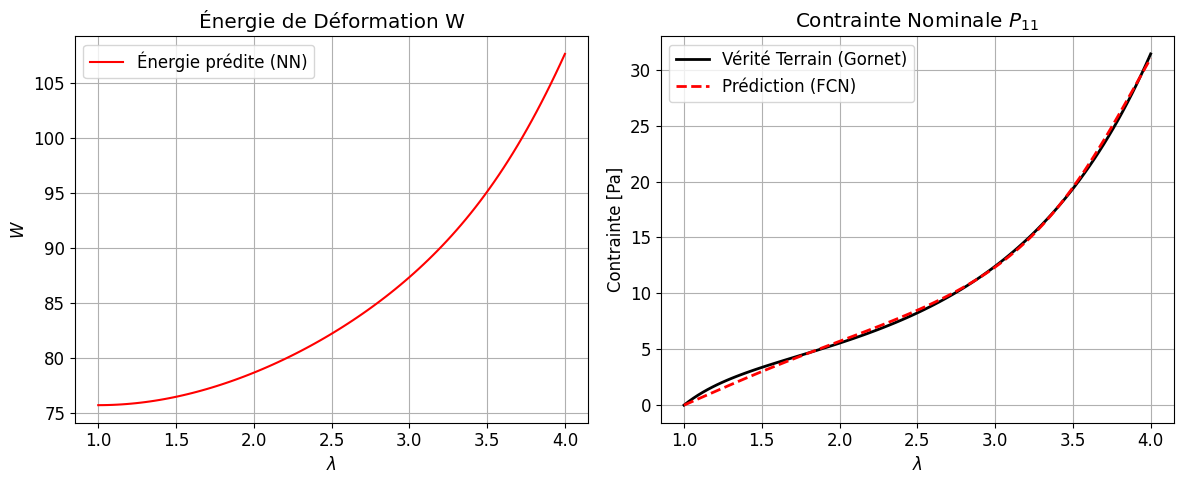

In [ ]:
lambdas_test = torch.linspace(1.0, 4.0, 100).to(device)
F_test = torch.zeros(100, 3, 3).to(device)

F_test[:, 0, 0] = lambdas_test
F_test[:, 1, 1] = 1.0 / torch.sqrt(lambdas_test)
F_test[:, 2, 2] = 1.0 / torch.sqrt(lambdas_test)

P_gt = gt_model.compute_stress(F_test).detach().cpu()

F_in = F_test.clone().detach().requires_grad_(True)
W_pred = model(F_in) # Le modèle sort l'énergie

P_raw = torch.autograd.grad(W_pred.sum(), F_in, create_graph=False)[0]

F_inv_T = torch.inverse(F_in).transpose(-2, -1)
sigma_raw = P_raw @ F_in.transpose(-2, -1)
p = sigma_raw[:, 2, 2].view(-1, 1, 1)
P_pred = (P_raw - p * F_inv_T).detach().cpu()


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lambdas_test.cpu(), W_pred.detach().cpu(), 'r-', label='Énergie prédite (NN)')
plt.title("Énergie de Déformation W")
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$W$")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(lambdas_test.cpu(), P_gt[:, 0, 0], 'k-', lw=2, label='Vérité Terrain (Gornet)')
plt.plot(lambdas_test.cpu(), P_pred[:, 0, 0], 'r--', lw=2, label='Prédiction (FCN)')
plt.title("Contrainte Nominale $P_{11}$")
plt.xlabel(r"$\lambda$")
plt.ylabel("Contrainte [Pa]")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()